In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)


subset_size = 1000
train_subset, _ = torch.utils.data.random_split(trainset, [subset_size, len(trainset)-subset_size])

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [5]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
loss_values = []

for epoch in range(1):   # only 1 epoch
    running_loss = 0

    for i, (images, labels) in enumerate(trainloader):
        if i > 20:
            break

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    loss_values.append(running_loss)
    print("Training Loss:", running_loss)

Training Loss: 49.28199815750122


In [8]:
correct = 0
total = 0

with torch.no_grad():
    for i, (images, labels) in enumerate(testloader):
        if i > 20:
            break

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 13.541666666666666


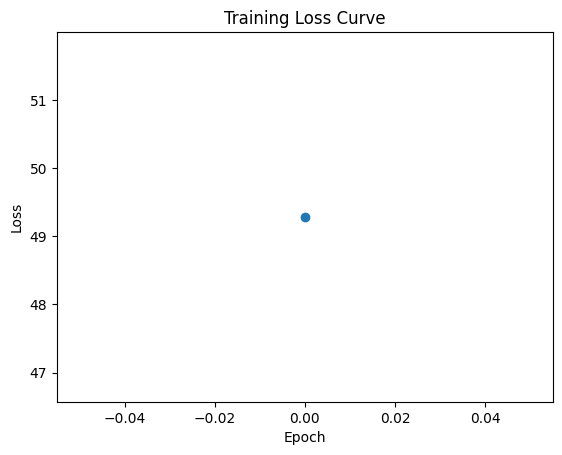

In [9]:
plt.plot(loss_values, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully")

Model saved successfully
